In [1]:
#Diable the warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
pip install yfinance


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [106]:
import yfinance as yf

wti = yf.download("CL=F", start="1983-01-01", end="2026-04-30")
brent = yf.download("BZ=F", start="1988-01-01", end="2026-05-02")

print(brent.tail())

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open Volume
Ticker            BZ=F        BZ=F        BZ=F        BZ=F   BZ=F
Date                                                             
2026-04-27  108.230003  109.790001  105.849998  106.500000  29439
2026-04-28  111.260002  112.690002  107.919998  108.300003  23451
2026-04-29  118.029999  120.300003  110.209999  111.010002  18031
2026-04-30  114.010002  126.099998  113.000000  119.980003  58572
2026-05-01  108.169998  112.430000  106.269997  111.010002  40576


In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np

# =========================
# 1. دانلود داده
# =========================

wti = yf.download("CL=F", start="1983-01-01", end="2026-04-30")
brent = yf.download("BZ=F", start="1988-01-01", end="2026-05-02")

# =========================
# 2. فقط ستون Close + rename
# =========================

wti = wti[["Close"]].rename(columns={"Close": "WTI"})
brent = brent[["Close"]].rename(columns={"Close": "Brent"})

# =========================
# 3. merge بر اساس تاریخ
# =========================

data = pd.merge(wti, brent, left_index=True, right_index=True, how="inner")

# =========================
# 4. حذف NA
# =========================

data = data.dropna()

# =========================
# 5. ساخت بازدهی
# =========================

returns = np.log(data / data.shift(1)).dropna()
returns.columns = ["WTI_ret", "Brent_ret"]

print(returns.head())

# =========================
# 4. تابع آمار توصیفی
# =========================

def descriptive_stats(series):
    return pd.Series({
        "Mean": series.mean(),
        "Std": series.std(),
        "Min": series.min(),
        "Max": series.max(),
        "Skewness": skew(series),
        "Kurtosis": kurtosis(series),
        "JB_stat": jarque_bera(series)[0],
        "JB_pvalue": jarque_bera(series)[1]
    })

desc_table = returns.apply(descriptive_stats)

print("\n=== Descriptive Statistics ===")
print(desc_table.T)

# =========================
# 5. آزمون ADF (ریشه واحد)
# =========================

def adf_test(series):
    result = adfuller(series)
    return {
        "ADF_stat": result[0],
        "p-value": result[1]
    }

print("\n=== ADF Test ===")
for col in returns.columns:
    res = adf_test(returns[col])
    print(f"{col}: {res}")

# =========================
# 6. Ljung-Box (خودهمبستگی)
# =========================

print("\n=== Ljung-Box Test (lag=10) ===")
for col in returns.columns:
    lb = acorr_ljungbox(returns[col], lags=[10], return_df=True)
    print(f"\n{col}")
    print(lb)

# =========================
# 7. ARCH LM test
# =========================

print("\n=== ARCH LM Test ===")
for col in returns.columns:
    arch_test = het_arch(returns[col])
    print(f"{col}: LM Stat={arch_test[0]}, p-value={arch_test[1]}")

In [107]:
import numpy as np
import pandas as pd

def parkinson_daily(df):
    log_hl = np.log(df['High'] / df['Low'])
    sigma_daily = np.sqrt((log_hl ** 2) / (4 * np.log(2)))
    return sigma_daily

In [108]:
def yang_zhang_rolling(df, window):

    df = df.copy()

    log_ho = np.log(df['High'] / df['Open'])
    log_lo = np.log(df['Low'] / df['Open'])
    log_co = np.log(df['Close'] / df['Open'])

    log_oc = np.log(df['Open'] / df['Close'].shift(1))
    log_cc = np.log(df['Close'] / df['Close'].shift(1))

    rs = log_ho * (log_ho - log_co) + log_lo * (log_lo - log_co)

    sigma_o = log_oc.rolling(window).var()
    sigma_c = log_cc.rolling(window).var()
    sigma_rs = rs.rolling(window).mean()

    k = 0.34 / (1.34 + (window + 1)/(window - 1))

    yz_var = sigma_o + k * sigma_c + (1 - k) * sigma_rs

    return np.sqrt(yz_var)

In [109]:
# فرض: df داری با OHLC
wti['YZ_vol'] =  yang_zhang_rolling(wti, window=30)



In [110]:
wti['Parkinson_daily'] = parkinson_daily(wti)

In [111]:
wti.columns = wti.columns.get_level_values(0)

wti=pd.DataFrame(wti[['YZ_vol','Parkinson_daily','Close']], columns=['YZ_vol','Parkinson_daily','Close'])
wti.head(2000)

,YZ_vol,Parkinson_daily,Close
Date,,,
2000-08-23,NaN,0.015769,32.049999
2000-08-24,NaN,0.015855,31.629999
2000-08-25,NaN,0.014773,32.049999
2000-08-28,NaN,0.019656,32.869999
2000-08-29,NaN,0.008607,32.720001
...,...,...,...
2008-08-15,0.024517,0.020468,113.769997
2008-08-18,0.024394,0.017700,112.870003
2008-08-19,0.024524,0.026364,114.529999


In [ ]:
pip install xlrd==2.0.1

In [113]:
gpr = pd.read_excel("data_gpr_daily_recent.xls")
gpr.to_csv("gpr.csv", index=False)
gpr = pd.read_csv("gpr.csv", parse_dates=['date'])
gpr=gpr[['date','GPRD','GPRD_ACT','GPRD_THREAT']]
gpr

,date,GPRD,GPRD_ACT,GPRD_THREAT
0,1985-01-01,230.039429,275.197601,153.027985
1,1985-01-02,115.676971,146.772064,87.444572
2,1985-01-03,97.428459,158.937653,29.459934
3,1985-01-04,157.366638,156.882248,157.026352
4,1985-01-05,81.361313,92.698143,77.319405
...,...,...,...,...
15087,2026-04-23,238.982849,304.427032,287.042480
15088,2026-04-24,262.010986,236.327881,331.992920
15089,2026-04-25,201.576126,227.749741,178.791321
15090,2026-04-26,167.390396,228.355453,190.471008


In [114]:
wti1=wti.reset_index()
wti2 = wti1.rename(columns={'Date': 'date'})
data = wti2.merge(gpr, on='date', how='inner')
data

,date,YZ_vol,Parkinson_daily,Close,GPRD,GPRD_ACT,GPRD_THREAT
0,2000-08-23,NaN,0.015769,32.049999,45.922840,30.520992,56.006546
1,2000-08-24,NaN,0.015855,31.629999,45.184216,33.783848,46.965111
2,2000-08-25,NaN,0.014773,32.049999,50.916500,41.802170,54.791214
3,2000-08-28,NaN,0.019656,32.869999,100.502663,112.216499,93.599640
4,2000-08-29,NaN,0.008607,32.720001,50.463490,21.560640,65.940239
...,...,...,...,...,...,...,...
6441,2026-04-21,0.066114,0.044120,92.129997,183.639145,126.743462,258.418274
6442,2026-04-22,0.059600,0.040346,92.959999,225.706024,225.011276,231.842010
6443,2026-04-23,0.058597,0.038373,95.849998,238.982849,304.427032,287.042480
6444,2026-04-24,0.057998,0.032600,94.400002,262.010986,236.327881,331.992920


In [115]:
gpr1=gpr.set_index('date')
wti3=wti2.set_index('date')

wti3

,YZ_vol,Parkinson_daily,Close
date,,,
2000-08-23,NaN,0.015769,32.049999
2000-08-24,NaN,0.015855,31.629999
2000-08-25,NaN,0.014773,32.049999
2000-08-28,NaN,0.019656,32.869999
2000-08-29,NaN,0.008607,32.720001
...,...,...,...
2026-04-23,0.058597,0.038373,95.849998
2026-04-24,0.057998,0.032600,94.400002
2026-04-27,0.057199,0.019244,96.370003


In [116]:
data = wti3.join(gpr1, how='inner')
data=data.dropna()
data

,YZ_vol,Parkinson_daily,Close,GPRD,GPRD_ACT,GPRD_THREAT
date,,,,,,
2000-10-05,0.031420,0.015329,30.650000,42.299347,42.169147,39.569889
2000-10-06,0.031326,0.008006,30.850000,82.246971,28.273727,117.915405
2000-10-09,0.031687,0.013124,31.879999,114.969810,93.125443,167.301758
2000-10-10,0.031802,0.018712,33.150002,103.622200,39.988350,138.975983
2000-10-11,0.031945,0.013334,33.150002,82.197708,65.555756,91.133293
...,...,...,...,...,...,...
2026-04-21,0.066114,0.044120,92.129997,183.639145,126.743462,258.418274
2026-04-22,0.059600,0.040346,92.959999,225.706024,225.011276,231.842010
2026-04-23,0.058597,0.038373,95.849998,238.982849,304.427032,287.042480


In [46]:
pip install arch


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [117]:
data['ret'] = np.log(data['Close'] / data['Close'].shift(1))
data=data.dropna()
data

,YZ_vol,Parkinson_daily,Close,GPRD,GPRD_ACT,GPRD_THREAT,ret
date,,,,,,,
2000-10-06,0.031326,0.008006,30.850000,82.246971,28.273727,117.915405,0.006504
2000-10-09,0.031687,0.013124,31.879999,114.969810,93.125443,167.301758,0.032842
2000-10-10,0.031802,0.018712,33.150002,103.622200,39.988350,138.975983,0.039064
2000-10-11,0.031945,0.013334,33.150002,82.197708,65.555756,91.133293,0.000000
2000-10-12,0.034314,0.036815,36.099998,28.646418,31.154448,25.985886,0.085250
...,...,...,...,...,...,...,...
2026-04-21,0.066114,0.044120,92.129997,183.639145,126.743462,258.418274,0.027734
2026-04-22,0.059600,0.040346,92.959999,225.706024,225.011276,231.842010,0.008969
2026-04-23,0.058597,0.038373,95.849998,238.982849,304.427032,287.042480,0.030615


In [118]:
from arch import arch_model

model = arch_model(
    data['ret'] ,
    mean='Constant',
    vol='EGARCH',
    p=1, o=1, q=1,   # o = asymmetry term
    dist='normal'
)

res = model.fit()
print(res.summary())

# استخراج ولاتیلیتی شرطی
egarch_vol = res.conditional_volatility

# اضافه کردن به دیتا فریم
data = data.copy()
data["EGARCH_vol"] = egarch_vol

print(data[["ret", "EGARCH_vol"]].head())

Iteration:      1,   Func. Count:      7,   Neg. LLF: 38113890.04464137
Iteration:      2,   Func. Count:     21,   Neg. LLF: 25810.340267713204
Iteration:      3,   Func. Count:     34,   Neg. LLF: 5352407136987.291
Iteration:      4,   Func. Count:     45,   Neg. LLF: 26135.939462594193
Iteration:      5,   Func. Count:     56,   Neg. LLF: -15316.421643585556
Iteration:      6,   Func. Count:     63,   Neg. LLF: 689161.8854892595
Iteration:      7,   Func. Count:     73,   Neg. LLF: -15351.760103205996
Iteration:      8,   Func. Count:     79,   Neg. LLF: -15351.798983004803
Iteration:      9,   Func. Count:     85,   Neg. LLF: -15351.800011543713
Iteration:     10,   Func. Count:     91,   Neg. LLF: -15351.800357595233
Iteration:     11,   Func. Count:     97,   Neg. LLF: -15351.80037317135
Iteration:     12,   Func. Count:    103,   Neg. LLF: -15351.800376034826
Iteration:     13,   Func. Count:    108,   Neg. LLF: -15351.800376014115
Optimization terminated successfully    (Exit m

In [119]:
from statsmodels.stats.diagnostic import acorr_ljungbox

std_resid = res.std_resid

acorr_ljungbox(std_resid, lags=[10], return_df=True)

,lb_stat,lb_pvalue
10,4.407625,0.927091


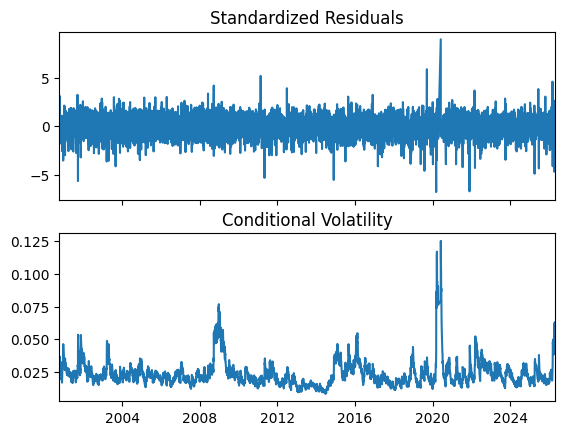

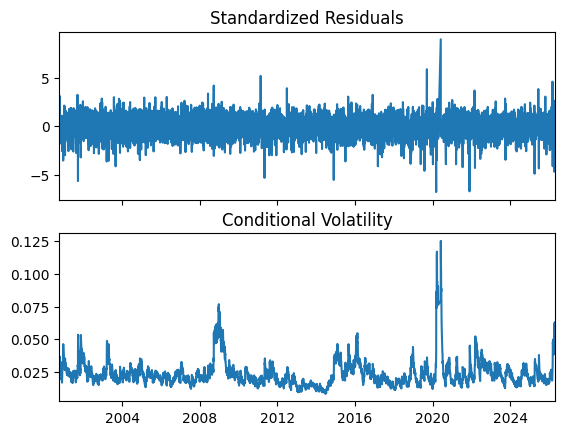

In [120]:
res.plot()

In [121]:
from statsmodels.stats.diagnostic import het_arch

het_arch(res.std_resid)

(11.488114951474339,
 0.32077367479562635,
 1.1488996289029898,
 0.3209381582266852)

In [ ]:
pip install pymc

In [122]:
import pymc as pm
import numpy as np

returns = data['ret'].values

with pm.Model() as model:

    sigma = pm.Exponential("sigma", 2.0)
    phi = pm.Beta("phi", 20, 1)   # نزدیک به 1

    h = pm.AR("h", rho=phi, sigma=sigma, shape=len(returns))

    r = pm.Normal("r", mu=0, sigma=np.exp(h/2), observed=returns)

    trace = pm.sample(
        draws=200,
        tune=100,
        chains=4,
        target_accept=0.95)


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 2 jobs)
NUTS: [sigma, phi, h]


Sampling 4 chains for 100 tune and 200 draw iterations (400 + 800 draws total) took 461 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


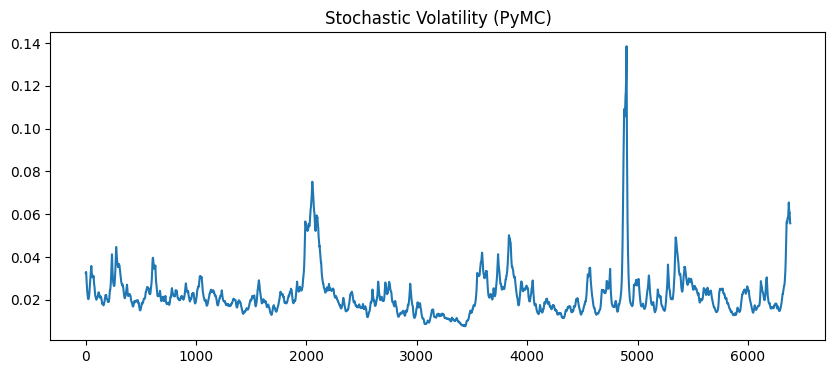

In [123]:
h_post = trace.posterior["h"]
volatility = np.exp(h_post / 2)
vol_mean = volatility.mean(dim=("chain","draw")).values
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(vol_mean)
plt.title("Stochastic Volatility (PyMC)")
plt.show()

In [124]:
data["SV_vol"] = vol_mean
data

,YZ_vol,Parkinson_daily,Close,GPRD,GPRD_ACT,GPRD_THREAT,ret,EGARCH_vol,SV_vol
date,,,,,,,,,
2000-10-06,0.031326,0.008006,30.850000,82.246971,28.273727,117.915405,0.006504,0.030925,0.032570
2000-10-09,0.031687,0.013124,31.879999,114.969810,93.125443,167.301758,0.032842,0.029096,0.032764
2000-10-10,0.031802,0.018712,33.150002,103.622200,39.988350,138.975983,0.039064,0.028964,0.032770
2000-10-11,0.031945,0.013334,33.150002,82.197708,65.555756,91.133293,0.000000,0.029220,0.032803
2000-10-12,0.034314,0.036815,36.099998,28.646418,31.154448,25.985886,0.085250,0.027185,0.033038
...,...,...,...,...,...,...,...,...,...
2026-04-21,0.066114,0.044120,92.129997,183.639145,126.743462,258.418274,0.027734,0.061754,0.058540
2026-04-22,0.059600,0.040346,92.959999,225.706024,225.011276,231.842010,0.008969,0.058323,0.057384
2026-04-23,0.058597,0.038373,95.849998,238.982849,304.427032,287.042480,0.030615,0.054156,0.056523


In [125]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# ستون‌هایی که می‌خواهیم پردازش کنیم
cols = ["GPRD", "GPRD_ACT", "GPRD_THREAT"]

# 1️⃣ ایجاد lag یک روزه
for col in cols:
    data[f"{col}_lag1"] = data[col].shift(1)

# 2️⃣ ایجاد growth rate روزانه
for col in cols:
    data[f"{col}_growth"] = data[col].pct_change()  # (today - yesterday)/yesterday

# 3️⃣ استانداردسازی/نرمال‌سازی
# ستون های اصلی، lag و growth را با هم استاندارد می‌کنیم
standard_cols = cols + [f"{c}_lag1" for c in cols]

scaler = StandardScaler()
data[standard_cols] = scaler.fit_transform(data[standard_cols])

# نمایش چند ردیف اول
data.head()

,YZ_vol,Parkinson_daily,Close,GPRD,GPRD_ACT,GPRD_THREAT,ret,EGARCH_vol,SV_vol,GPRD_lag1,GPRD_ACT_lag1,GPRD_THREAT_lag1,GPRD_growth,GPRD_ACT_growth,GPRD_THREAT_growth
date,,,,,,,,,,,,,,,
2000-10-06,0.031326,0.008006,30.850000,-0.553193,-0.866724,-0.070672,0.006504,0.030925,0.032570,NaN,NaN,NaN,NaN,NaN,NaN
2000-10-09,0.031687,0.013124,31.879999,-0.085752,-0.265100,0.617013,0.032842,0.029096,0.032764,-0.553120,-0.866575,-0.070675,0.397861,2.293709,0.418829
2000-10-10,0.031802,0.018712,33.150002,-0.247851,-0.758048,0.222588,0.039064,0.028964,0.032770,-0.085713,-0.264969,0.616957,-0.098701,-0.570597,-0.169309
2000-10-11,0.031945,0.013334,33.150002,-0.553897,-0.520862,-0.443603,0.000000,0.029220,0.032803,-0.247800,-0.757903,0.222562,-0.206756,0.639371,-0.344251
2000-10-12,0.034314,0.036815,36.099998,-1.318871,-0.840000,-1.350754,0.085250,0.027185,0.033038,-0.553823,-0.520723,-0.443576,-0.651494,-0.524764,-0.714858


In [85]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = data[['GPRD_ACT','GPRD_THREAT',
          'GPRD_ACT_lag1','GPRD_THREAT_lag1']].dropna()

vif = pd.DataFrame()
vif["Variable"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i)
              for i in range(X.shape[1])]

print(vif)

           Variable       VIF
0          GPRD_ACT  1.847641
1       GPRD_THREAT  1.899806
2     GPRD_ACT_lag1  1.845630
3  GPRD_THREAT_lag1  1.902496


In [137]:
import statsmodels.formula.api as smf

model = smf.quantreg('YZ_vol	~ GPRD_THREAT + GPRD_ACT ', data)
res = model.fit(q=0.75)
print(res.summary())

                         QuantReg Regression Results                          
Dep. Variable:                 YZ_vol   Pseudo R-squared:              0.03284
Model:                       QuantReg   Bandwidth:                    0.001452
Method:                 Least Squares   Sparsity:                      0.03107
Date:                Fri, 15 May 2026   No. Observations:                 6384
Time:                        16:08:01   Df Residuals:                     6381
                                        Df Model:                            2
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       0.0256      0.000    152.105      0.000       0.025       0.026
GPRD_THREAT     0.0008      0.000      4.040      0.000       0.000       0.001
GPRD_ACT        0.0021      0.000     10.914      0.000       0.002       0.003


In [138]:
data.to_csv("data.csv")

In [139]:
import numpy as np
import pandas as pd
from itertools import combinations

In [141]:
df = pd.read_csv("data.csv").dropna()
df = df.copy()
df=df.reset_index()
# 🔥 استفاده از ستون واقعی date (خیلی مهم)
df["date"] = pd.to_datetime(df["date"])
df = df.set_index("date")

# حذف timezone اگر وجود دارد
df.index = df.index.tz_localize(None)

# مرتب‌سازی زمانی
df = df.sort_index()
y = df["YZ_vol"].values
X = df[["GPRD_THREAT", "GPRD_ACT"]].values

T, k = X.shape

In [142]:
model_list = []

for i in range(1, k+1):
    for combo in combinations(range(k), i):
        model_list.append(list(combo))

M = len(model_list)


In [143]:
alpha = 0.99      # model forgetting
lambda_ = 0.99    # parameter forgetting

weights = np.ones(M) / M

y_hat = np.zeros(T)
weights_time = np.zeros((T, M))

In [144]:
theta = []
P = []

for m in range(M):
    p = len(model_list[m]) + 1
    theta.append(np.zeros((p,1)))
    P.append(np.eye(p) * 1000)

In [145]:
for t in range(1, T):

    pred = np.zeros(M)
    loglik = np.zeros(M)

    for m in range(M):

        idx = model_list[m]

        x_tm1 = np.concatenate(([1], X[t-1, idx])).reshape(-1,1)

        th = theta[m]
        Pm = P[m]

        # prediction
        y_pred = float(x_tm1.T @ th)
        pred[m] = y_pred

        # error
        e = y[t] - y_pred

        # variance (adaptive)
        sigma2 = e**2 + 1e-6

        # Kalman gain (stable)
        S = lambda_ + (x_tm1.T @ Pm @ x_tm1)[0,0]
        K = (Pm @ x_tm1) / S

        # update theta
        th_new = th + K * e

        # Joseph form (numerical stability)
        I = np.eye(Pm.shape[0])
        P_new = (I - K @ x_tm1.T) @ Pm @ (I - K @ x_tm1.T).T + K * sigma2 * K.T
        P_new = P_new / lambda_

        theta[m] = th_new
        P[m] = P_new

        # log-likelihood (important!)
        loglik[m] = -0.5*(np.log(2*np.pi*sigma2) + (e**2)/sigma2)

    # 🔥 log-weight update (stable)
    logw = alpha * np.log(weights + 1e-12) + loglik
    logw = logw - np.max(logw)

    weights = np.exp(logw)
    weights = weights / np.sum(weights)

    # DMA prediction
    y_hat[t] = np.sum(weights * pred)
    weights_time[t,:] = weights

In [146]:
importance = np.zeros((T, k))

for t in range(T):
    for j in range(k):
        importance[t,j] = np.sum(
            weights_time[t,:] *
            np.array([j in model for model in model_list])
        )

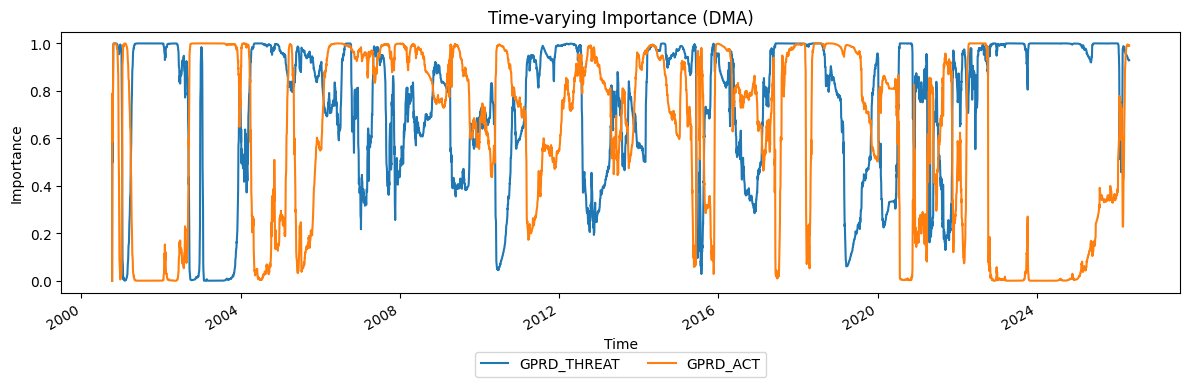

In [147]:
import matplotlib.pyplot as plt
import pandas as pd

# =========================
# 1. تاریخ واقعی
# =========================

dates = pd.to_datetime(df.index)

# =========================
# 2. رسم نمودار
# =========================

plt.figure(figsize=(12,4))

var_names = ["GPRD_THREAT", "GPRD_ACT"]

for j in range(k):
    plt.plot(dates, importance[:, j], label=var_names[j])

# =========================
# 3. فرمت محور زمان
# =========================

plt.gcf().autofmt_xdate()

plt.title("Time-varying Importance (DMA)")
plt.xlabel("Time")
plt.ylabel("Importance")

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=2)
plt.tight_layout()
plt.savefig("figure.png", dpi=300, bbox_inches='tight')
plt.show()

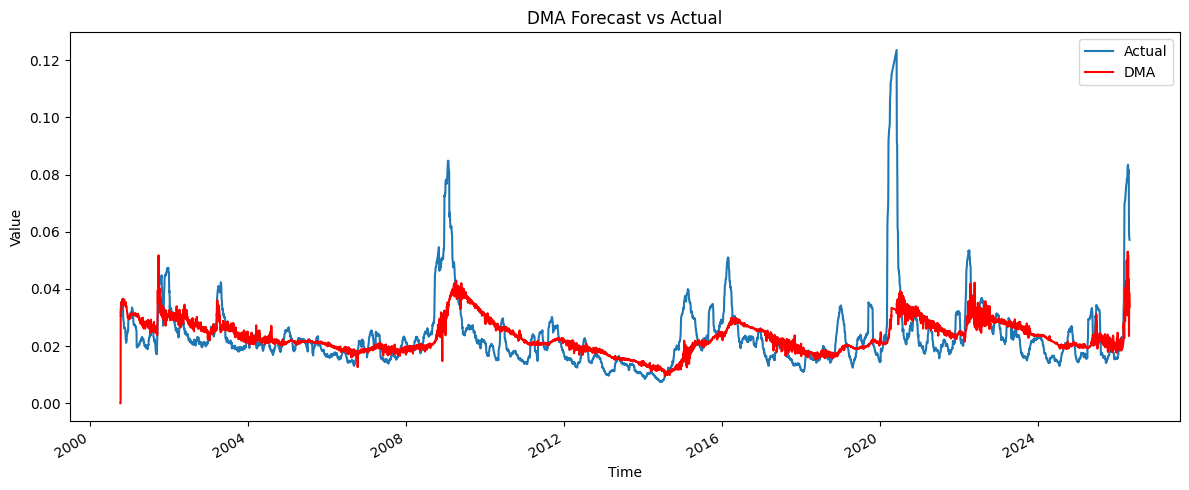

In [151]:
import matplotlib.pyplot as plt
import pandas as pd

# =========================
# 1. اطمینان از تاریخ درست
# =========================

dates = pd.to_datetime(df.index)

# =========================
# 2. رسم نمودار
# =========================

plt.figure(figsize=(12,5))

plt.plot(dates, y, label="Actual")
plt.plot(dates, y_hat, label="DMA", color="red")

# =========================
# 3. فرمت تاریخ محور X
# =========================

plt.gcf().autofmt_xdate()  # چرخش خودکار تاریخ‌ها

plt.title("DMA Forecast vs Actual")
plt.xlabel("Time")
plt.ylabel("Value")

plt.legend()
plt.tight_layout()
plt.savefig("5.png", dpi=300, bbox_inches='tight')
plt.show()

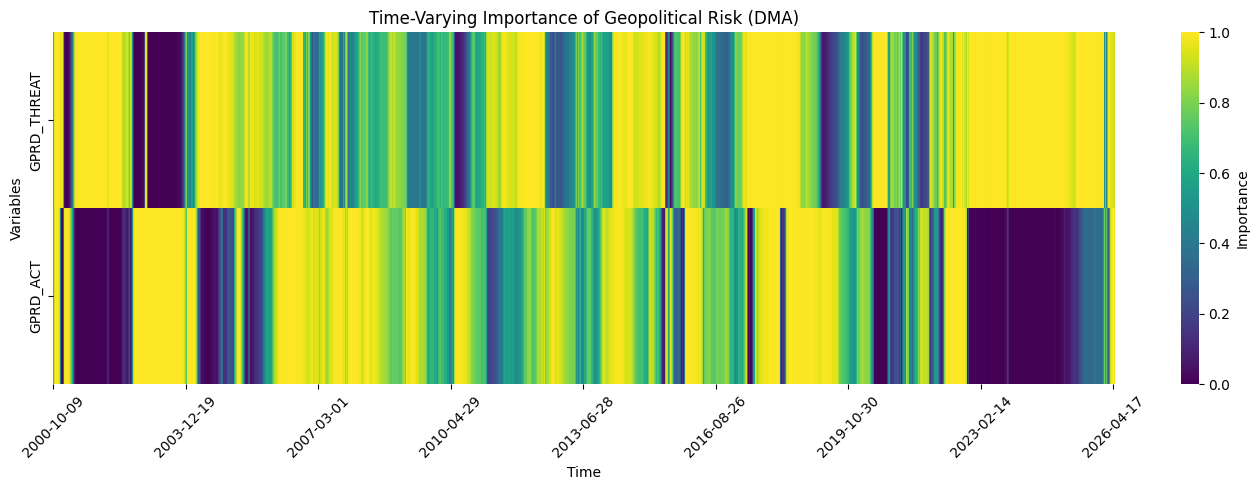

In [149]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# =========================
# 1. ساخت صحیح DataFrame (اول این باید باشد)
# =========================

var_names = ["GPRD_THREAT", "GPRD_ACT"]

importance_df = pd.DataFrame(
    importance,
    columns=var_names,
    index=pd.to_datetime(df.index)
)

# حذف میلی‌ثانیه/نانوثانیه (تمیز کردن تاریخ)
importance_df.index = importance_df.index.floor('D')

# =========================
# 2. رسم heatmap
# =========================

plt.figure(figsize=(14,5))

ax = sns.heatmap(
    importance_df.T,
    cmap="viridis",
    cbar_kws={'label': 'Importance'},
    xticklabels=False   # جلوگیری از بهم‌ریختگی
)

# =========================
# 3. تنظیم محور X به تاریخ واقعی
# =========================

step = max(1, len(importance_df)//8)  # فقط 8 تا لیبل تمیز

plt.xticks(
    ticks=[i for i in range(0, len(importance_df), step)],
    labels=importance_df.index[::step].strftime('%Y-%m-%d'),
    rotation=45
)

# =========================
# 4. لیبل‌ها
# =========================

plt.title("Time-Varying Importance of Geopolitical Risk (DMA)")
plt.xlabel("Time")
plt.ylabel("Variables")

plt.tight_layout()
plt.savefig("figure2.png", dpi=300, bbox_inches='tight')
plt.show()

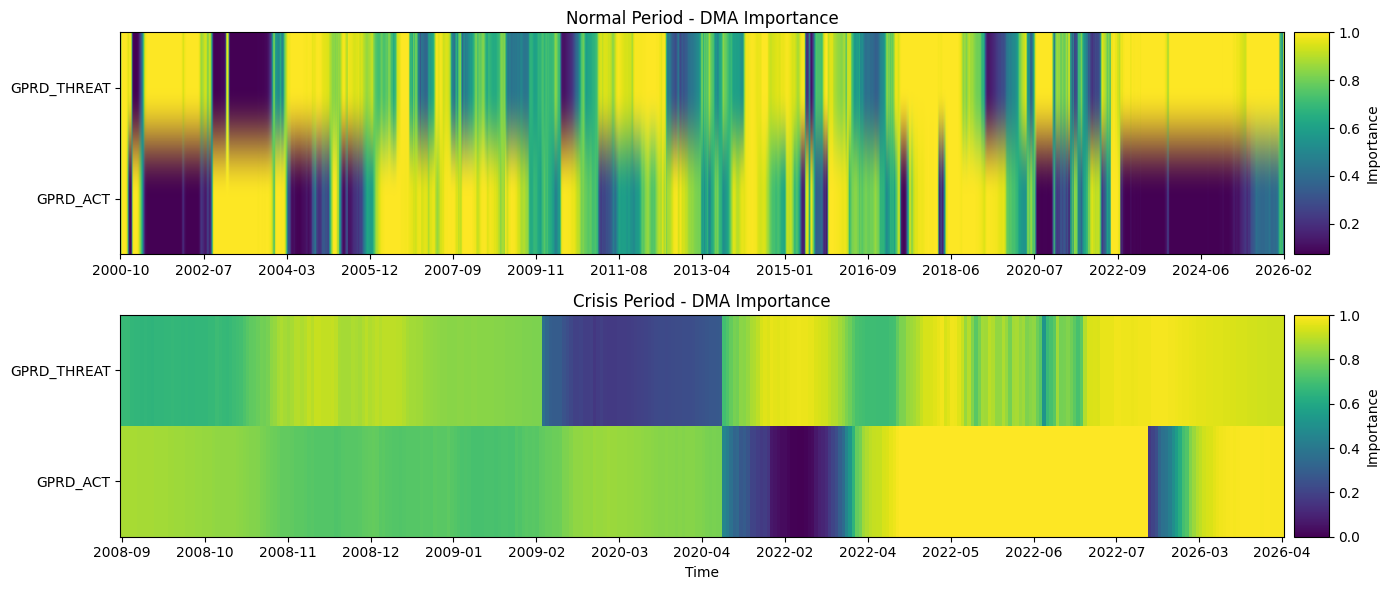

In [150]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# 1. FIX تاریخ (درست)
# =========================================================

df = df.copy()
df = df.reset_index()

df["date"] = pd.to_datetime(df["date"])
df = df.set_index("date")
df.index = df.index.tz_localize(None)
df = df.sort_index()

# =========================================================
# 2. importance alignment
# =========================================================

importance = np.array(importance)

n = min(len(df), len(importance))

df = df.iloc[:n]
importance = importance[:n]

var_names = ["GPRD_THREAT", "GPRD_ACT"]

importance_df = pd.DataFrame(
    importance,
    columns=var_names,
    index=df.index
)

# =========================================================
# 3. crisis
# =========================================================

crises = {
    "GFC": ("2008-09-01", "2009-03-01"),
    "COVID": ("2020-02-01", "2020-06-01"),
    "Ukraine": ("2022-02-01", "2022-08-01"),
    "MidelEastWar": ("2026-02-28", "2026-04-27")
}

crises = {k: (pd.to_datetime(v[0]), pd.to_datetime(v[1])) for k,v in crises.items()}

# crisis mask
crisis_mask = np.zeros(len(importance_df), dtype=bool)

for k,(s,e) in crises.items():
    crisis_mask |= (importance_df.index >= s) & (importance_df.index <= e)

normal_df = importance_df[~crisis_mask]
crisis_df = importance_df[crisis_mask]

# =========================================================
# 4. PLOT (IMPORTANT FIX HERE)
# =========================================================

fig, ax = plt.subplots(2, 1, figsize=(14,6), sharey=True)

# ---------------- NORMAL ----------------
im1 = ax[0].imshow(
    normal_df.T.values,
    aspect='auto',
    cmap='viridis'
)

ax[0].set_title("Normal Period - DMA Importance")

ax[0].set_yticks(range(len(var_names)))
ax[0].set_yticklabels(var_names)

ax[0].set_xticks(np.linspace(0, len(normal_df)-1, 15))
ax[0].set_xticklabels(normal_df.index[np.linspace(0, len(normal_df)-1, 15, dtype=int)].strftime('%Y-%m'))

# ---------------- CRISIS ----------------
im2 = ax[1].imshow(
    crisis_df.T.values,
    aspect='auto',
    cmap='viridis'
)

ax[1].set_title("Crisis Period - DMA Importance")

ax[1].set_yticks(range(len(var_names)))
ax[1].set_yticklabels(var_names)

if len(crisis_df) > 0:
    ax[1].set_xticks(np.linspace(0, len(crisis_df)-1, 15))
    ax[1].set_xticklabels(crisis_df.index[np.linspace(0, len(crisis_df)-1, 15, dtype=int)].strftime('%Y-%m'))

# =========================================================
# 5. colorbar
# =========================================================

from mpl_toolkits.axes_grid1 import make_axes_locatable

divider = make_axes_locatable(ax[1])
divider1 = make_axes_locatable(ax[0])
cax = divider.append_axes("right", size="3%", pad=0.1)
cax1 = divider1.append_axes("right", size="3%", pad=0.1)
cbar = fig.colorbar(im1, cax=cax)
cbar1 = fig.colorbar(im2, cax=cax1)
cbar.set_label("Importance")
cbar1.set_label("Importance")
ax[1].set_xlabel("Time")

plt.tight_layout()
plt.savefig("figure3.png", dpi=300, bbox_inches='tight')
plt.show()

In [92]:
import numpy as np

# ======================================
# Candidate DMA Models
# ======================================

model_list = [

    # contemporaneous effects
    [0],                # ACT
    [1],                # THREAT
    [0,1],              # ACT + THREAT

    # persistence effects
    [0,2],              # ACT + ACT_lag1
    [1,3],              # THREAT + THREAT_lag1

    # mixed dynamic effects
    [0,1,2],            # ACT + THREAT + ACT_lag1
    [0,1,3],            # ACT + THREAT + THREAT_lag1

    # full dynamic model
    [0,1,2,3]
]

M = len(model_list)

# ======================================
# DMA Parameters
# ======================================

alpha = 0.99      # model forgetting
lambda_ = 0.99    # parameter forgetting

weights = np.ones(M) / M

y_hat = np.zeros(T)
weights_time = np.zeros((T, M))

theta = []
P = []

# ======================================
# Initialization
# ======================================

for m in range(M):

    p = len(model_list[m]) + 1

    theta.append(np.zeros((p,1)))

    P.append(np.eye(p) * 1000)

# ======================================
# DMA Recursion
# ======================================

for t in range(1, T):

    pred = np.zeros(M)
    loglik = np.zeros(M)

    for m in range(M):

        idx = model_list[m]

        x_tm1 = np.concatenate(
            ([1], X[t-1, idx])
        ).reshape(-1,1)

        th = theta[m]
        Pm = P[m]

        # prediction
        y_pred = float(x_tm1.T @ th)

        pred[m] = y_pred

        # forecast error
        e = y[t] - y_pred

        # adaptive variance
        sigma2 = e**2 + 1e-6

        # Kalman gain
        S = lambda_ + (x_tm1.T @ Pm @ x_tm1)[0,0]

        K = (Pm @ x_tm1) / S

        # state update
        th_new = th + K * e

        # Joseph covariance update
        I = np.eye(Pm.shape[0])

        P_new = (
            (I - K @ x_tm1.T)
            @ Pm
            @ (I - K @ x_tm1.T).T
            + K * sigma2 * K.T
        )

        P_new = P_new / lambda_

        theta[m] = th_new
        P[m] = P_new

        # predictive likelihood
        loglik[m] = -0.5 * (
            np.log(2*np.pi*sigma2)
            + (e**2)/sigma2
        )

    # ======================================
    # DMA Weight Updating
    # ======================================

    logw = alpha * np.log(weights + 1e-12) + loglik

    logw = logw - np.max(logw)

    weights = np.exp(logw)

    weights = weights / np.sum(weights)

    # DMA forecast
    y_hat[t] = np.sum(weights * pred)

    weights_time[t,:] = weights

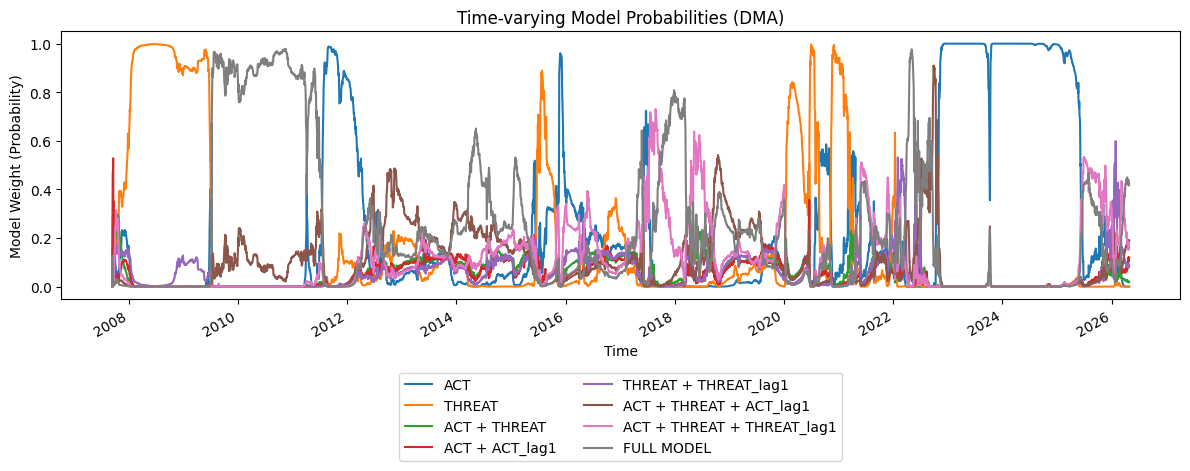

In [93]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# =========================
# 1. تاریخ واقعی
# =========================

dates = pd.to_datetime(df.index)

# =========================
# 2. importance = weights DMA
# =========================

importance = weights_time   # (T × M)

# =========================
# 3. نام مدل‌ها (دینامیک از model_list)
# =========================

model_names = [
    "ACT",
    "THREAT",
    "ACT + THREAT",
    "ACT + ACT_lag1",
    "THREAT + THREAT_lag1",
    "ACT + THREAT + ACT_lag1",
    "ACT + THREAT + THREAT_lag1",
    "FULL MODEL"
]

k = len(model_names)

# =========================
# 4. رسم نمودار
# =========================

plt.figure(figsize=(12,5))

for j in range(k):
    plt.plot(dates[:len(importance)], importance[:, j], label=model_names[j])

# =========================
# 5. تنظیمات محور زمان
# =========================

plt.gcf().autofmt_xdate()

plt.title("Time-varying Model Probabilities (DMA)")
plt.xlabel("Time")
plt.ylabel("Model Weight (Probability)")

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.25), ncol=2)

plt.tight_layout()
plt.savefig("DMA_weights.png", dpi=300, bbox_inches='tight')
plt.show()

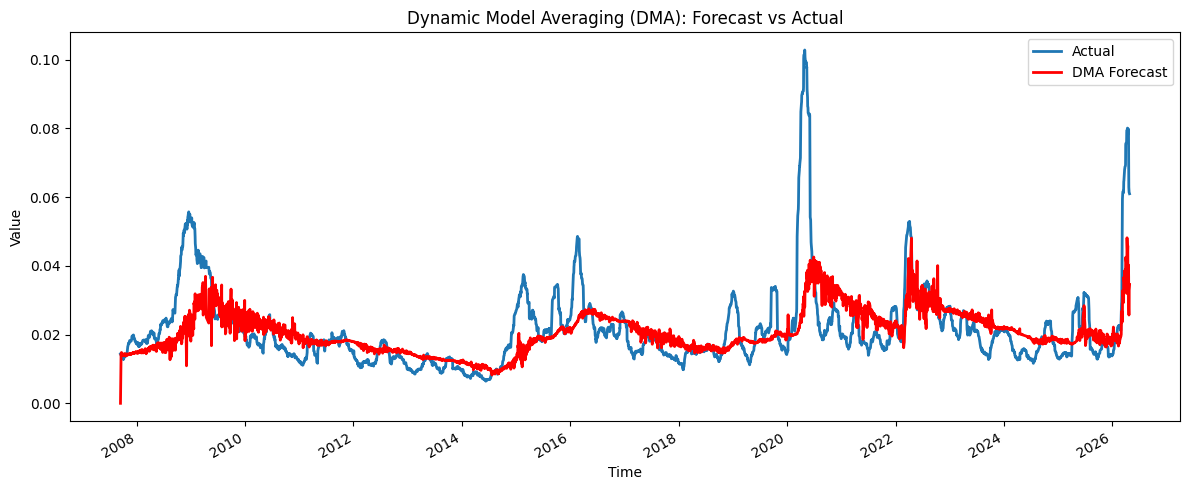

In [95]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# =========================
# 1. تاریخ
# =========================

dates = pd.to_datetime(df.index)

# =========================
# 2. هم‌تراز کردن سری‌ها
# =========================

y_plot = y.copy()
y_hat_plot = y_hat.copy()

# DMA از t=1 شروع شده → مقدار اول را حذف/NaN می‌کنیم
y_plot = y_plot[1:]
y_hat_plot = y_hat_plot[1:]
dates_plot = dates[1:]

# =========================
# 3. حذف احتمالی NaN
# =========================

mask = ~np.isnan(y_hat_plot)

y_plot = y_plot[mask]
y_hat_plot = y_hat_plot[mask]
dates_plot = dates_plot[mask]

# =========================
# 4. رسم نمودار
# =========================

plt.figure(figsize=(12,5))

plt.plot(dates_plot, y_plot, label="Actual", linewidth=2)
plt.plot(dates_plot, y_hat_plot, label="DMA Forecast", color="red", linewidth=2)

# =========================
# 5. تنظیم محور زمان
# =========================

plt.gcf().autofmt_xdate()

plt.title("Dynamic Model Averaging (DMA): Forecast vs Actual")
plt.xlabel("Time")
plt.ylabel("Value")

plt.legend()
plt.tight_layout()
plt.savefig("DMA_forecast.png", dpi=300, bbox_inches='tight')
plt.show()

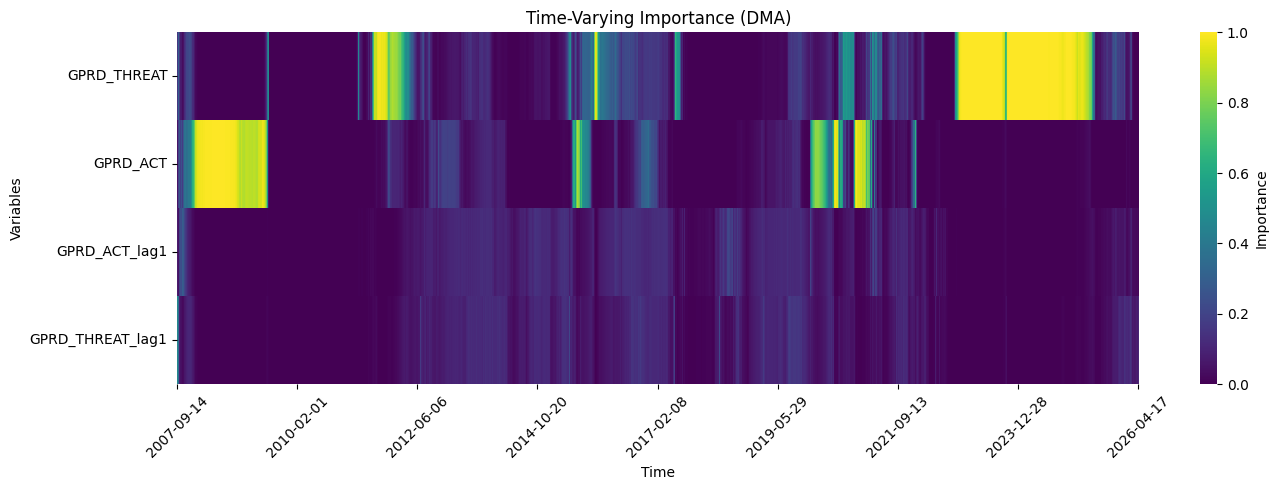

In [97]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# =========================
# 1. متغیرها
# =========================

var_names = [
    "GPRD_THREAT",
    "GPRD_ACT",
    "GPRD_ACT_lag1",
    "GPRD_THREAT_lag1"
]

# =========================
# 2. هم‌ترازی درست (مهم‌ترین بخش)
# =========================

importance_clean = importance[1:, :len(var_names)]  # حذف t=0

index_clean = pd.to_datetime(df.index)[1:1+importance_clean.shape[0]]

# =========================
# 3. ساخت DataFrame
# =========================

importance_df = pd.DataFrame(
    importance_clean,
    columns=var_names,
    index=index_clean
)

importance_df.index = importance_df.index.floor('D')

# =========================
# 4. Heatmap
# =========================

plt.figure(figsize=(14,5))

sns.heatmap(
    importance_df.T,
    cmap="viridis",
    cbar_kws={'label': 'Importance'},
    xticklabels=False
)

# =========================
# 5. محور زمان
# =========================

step = max(1, len(importance_df)//8)

plt.xticks(
    ticks=np.arange(0, len(importance_df), step),
    labels=importance_df.index[::step].strftime('%Y-%m-%d'),
    rotation=45
)

plt.title("Time-Varying Importance (DMA)")
plt.xlabel("Time")
plt.ylabel("Variables")

plt.tight_layout()
plt.show()

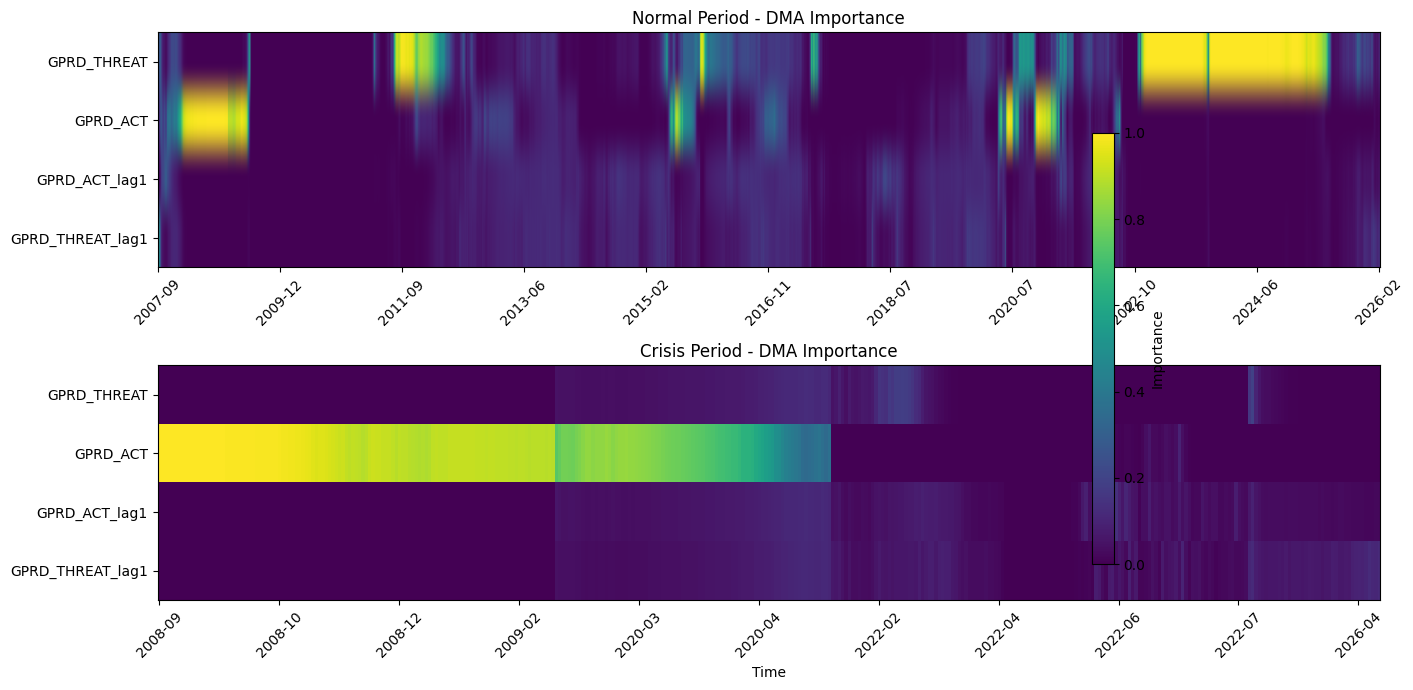

In [99]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# 1. Clean time index
# =========================================================

df = df.copy()
df = df.reset_index()

df["date"] = pd.to_datetime(df["date"])
df = df.set_index("date")
df.index = df.index.tz_localize(None)
df = df.sort_index()

# =========================================================
# 2. Align importance safely (IMPORTANT FIX)
# =========================================================

importance = np.array(importance)

n = min(len(df), importance.shape[0])

df = df.iloc[:n]
importance = importance[:n]

var_names = [
    "GPRD_THREAT",
    "GPRD_ACT",
    "GPRD_ACT_lag1",
    "GPRD_THREAT_lag1"
]

importance_df = pd.DataFrame(
    importance[:, :len(var_names)],
    columns=var_names,
    index=df.index
)

# =========================================================
# 3. Crisis definition
# =========================================================

crises = {
    "GFC": ("2008-09-01", "2009-03-01"),
    "COVID": ("2020-02-01", "2020-06-01"),
    "Ukraine": ("2022-02-01", "2022-08-01"),
    "ME_War": ("2026-02-28", "2026-04-27")
}

crises = {
    k: (pd.to_datetime(v[0]), pd.to_datetime(v[1]))
    for k, v in crises.items()
}

# =========================================================
# 4. Crisis mask (AFTER alignment)
# =========================================================

crisis_mask = np.zeros(len(importance_df), dtype=bool)

for _, (s, e) in crises.items():
    crisis_mask |= (importance_df.index >= s) & (importance_df.index <= e)

normal_df = importance_df.loc[~crisis_mask]
crisis_df = importance_df.loc[crisis_mask]

# =========================================================
# 5. Plot
# =========================================================

fig, ax = plt.subplots(2, 1, figsize=(14, 7), sharey=True)

# ---------------- NORMAL ----------------
im1 = ax[0].imshow(
    normal_df.T.values,
    aspect='auto',
    cmap='viridis'
)

ax[0].set_title("Normal Period - DMA Importance")
ax[0].set_yticks(range(len(var_names)))
ax[0].set_yticklabels(var_names)

if len(normal_df) > 0:
    step = max(1, len(normal_df)//10)
    xticks = np.arange(0, len(normal_df), step)

    ax[0].set_xticks(xticks)
    ax[0].set_xticklabels(
        normal_df.index[xticks].strftime('%Y-%m'),
        rotation=45
    )

# ---------------- CRISIS ----------------
im2 = ax[1].imshow(
    crisis_df.T.values,
    aspect='auto',
    cmap='viridis'
)

ax[1].set_title("Crisis Period - DMA Importance")
ax[1].set_yticks(range(len(var_names)))
ax[1].set_yticklabels(var_names)

if len(crisis_df) > 0:
    step = max(1, len(crisis_df)//10)
    xticks = np.arange(0, len(crisis_df), step)

    ax[1].set_xticks(xticks)
    ax[1].set_xticklabels(
        crisis_df.index[xticks].strftime('%Y-%m'),
        rotation=45
    )

# =========================================================
# 6. SINGLE colorbar (FIXED)
# =========================================================

cbar = fig.colorbar(im1, ax=ax, shrink=0.8)
cbar.set_label("Importance")

ax[1].set_xlabel("Time")

plt.tight_layout()
plt.savefig("DMA_crisis.png", dpi=300, bbox_inches='tight')
plt.show()